<div style="background-color:#ffffcc; padding:10px; border-left:5px solid #f1c40f;">

 ## 1st Plot **Budworm_tree(0 -10)**

</div>

In [1]:
# import necessary libaries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


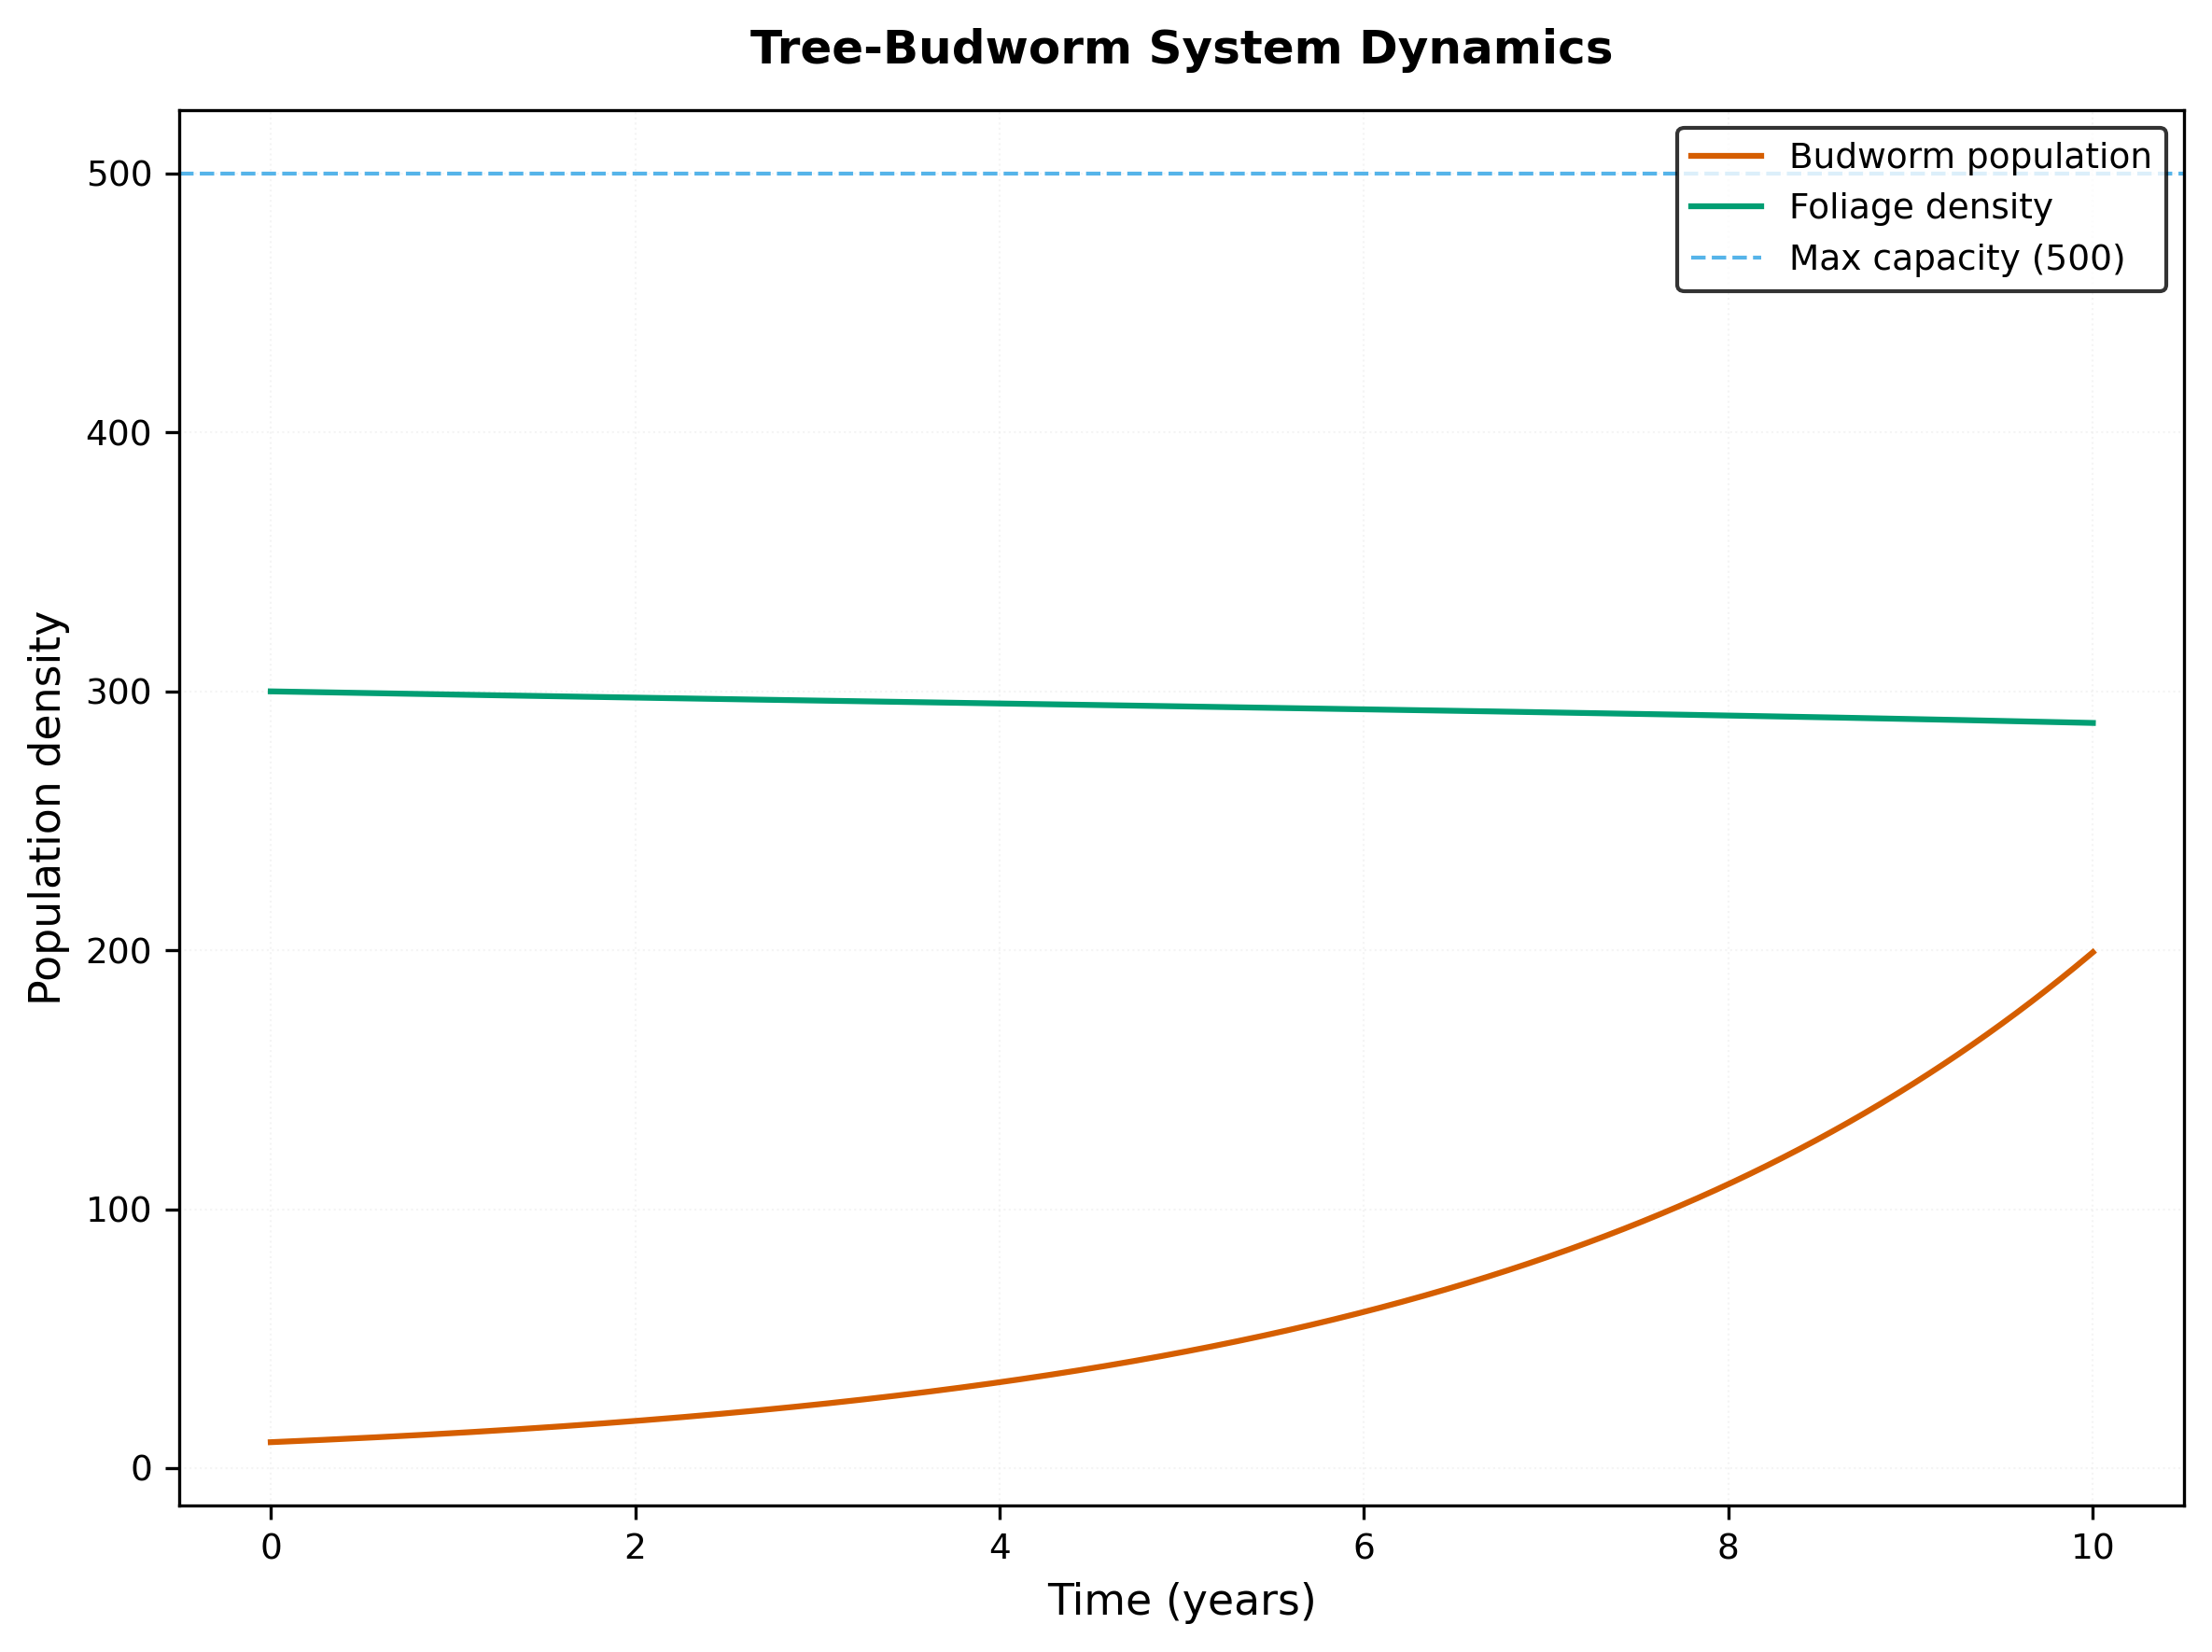


                    EQUILIBRIUM ANALYSIS                    
Parameter                           Value           Units
------------------------------------------------------------
Budworm equilibrium                199.24   budworms/area
Foliage equilibrium                287.81   branches/area
Capacity utilization                 57.6               %


In [2]:


# Parameters (carefully tuned for stability)
params = {
    'r_B': 0.3,      # Reduced growth rate
    'K_B': 1000,
    'beta': 0.6,
    'alpha': 200,
    'r_S': 0.1,
    'K_S': 500,
    'lambda': 0.05,
    'P': 0.005,
    'E0': 0.9,
    'eps': 1e-8      # Numerical safeguard
}

# Initial conditions
B0 = 10
S0 = 300
y0 = np.array([B0, S0 * params['E0']], dtype=np.float64)

# Time span
t_span = (0, 10)
t_eval = np.linspace(*t_span, 1000)

def model(t, y, params):
    B, ES = y
    eps = params['eps']
    
    # Safeguarded calculations
    safe_ES = max(ES, eps)
    S = safe_ES / params['E0']
    
    # Budworm dynamics (fully safeguarded)
    carrying_term = params['K_B'] * safe_ES + eps
    pred_term = (B**2) / (params['alpha']**2 + B**2 + eps)
    
    dBdt = params['r_B'] * B * (1 - B / carrying_term) - params['beta'] * pred_term
    
    # Foliage dynamics
    dESdt = (params['r_S'] * safe_ES * (1 - safe_ES/(params['K_S'] + eps)) 
             - params['lambda'] * safe_ES 
             - params['P'] * B)
    
    return np.array([dBdt, dESdt], dtype=np.float64)

# Using Radau solver (best for stiff problems)
sol = solve_ivp(model, t_span, y0, args=(params,),
                method='Radau', t_eval=t_eval,
                rtol=1e-6, atol=1e-8)

# Process results
B = sol.y[0]
S = sol.y[1] / params['E0']

# Set the default font to 'DejaVu Sans' which is available in most systems
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # Fallback to a common sans-serif font

# Publication-quality figure with clean styling
plt.figure(figsize=(8, 6), dpi=300)  # Standard single-column size

# Scientific color palette (colorblind-friendly)
colors = {
    'budworm': '#D55E00',  # Vermillion
    'foliage': '#009E73',  # Green
    'capacity': '#56B4E9'  # Blue
}

# Set style with default font
plt.rcParams.update({
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'grid.color': '#EAEAEA',
    'font.size': 10,
    'legend.frameon': True,
    'legend.framealpha': 0.8
})

# Plot data with enhanced styling
plt.plot(sol.t, B, label='Budworm population',
         color=colors['budworm'], linewidth=1.5)
plt.plot(sol.t, S, label='Foliage density',
         color=colors['foliage'], linewidth=1.5)

# Reference line
plt.axhline(y=params['K_S'], linestyle='--', 
            color=colors['capacity'], linewidth=1.0,
            label=f'Max capacity ({params["K_S"]})')

# Axis labels
plt.xlabel('Time (years)', fontsize=11)
plt.ylabel('Population density', fontsize=11)
plt.title('Tree-Budworm System Dynamics', fontsize=12, pad=12, weight='bold')

# Legend
legend = plt.legend(loc='upper right', fontsize=9)
legend.get_frame().set_edgecolor('black')

# Grid and ticks
plt.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)
plt.gca().tick_params(axis='both', which='major', labelsize=9)

# Adjust layout
plt.tight_layout()

# Save in multiple formats
plt.savefig('TreeBudworm_Dynamics.png', dpi=600, bbox_inches='tight')
plt.savefig('TreeBudworm_Dynamics.pdf', bbox_inches='tight')

plt.show()

# Console output
print("\n" + "="*60)
print(f"{'EQUILIBRIUM ANALYSIS':^60}")
print("="*60)
print(f"{'Parameter':<25} {'Value':>15} {'Units':>15}")
print("-"*60)
print(f"{'Budworm equilibrium':<25} {B[-1]:15.2f} {'budworms/area':>15}")
print(f"{'Foliage equilibrium':<25} {S[-1]:15.2f} {'branches/area':>15}")
print(f"{'Capacity utilization':<25} {S[-1]/params['K_S']*100:15.1f} {'%':>15}")
print("="*60)

<div style="background-color:#ffffcc; padding:10px; border-left:5px solid #f1c40f;">

 ## 2nd Plot **Budworm_tree(0 -20)**

</div>

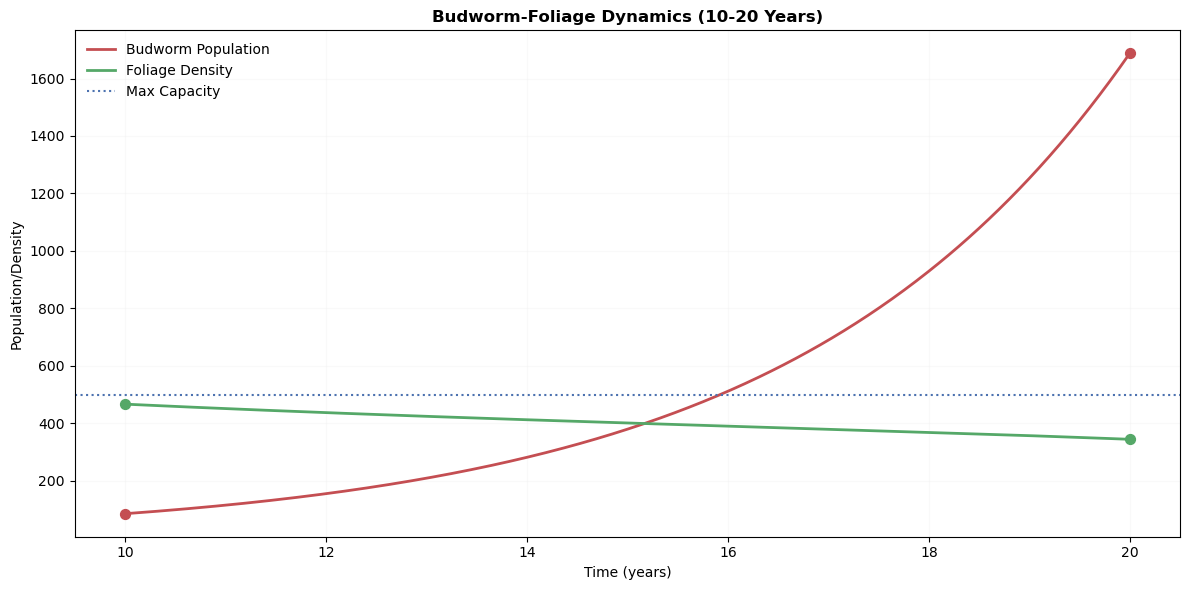


Ecosystem Dynamics Summary (10-20 Years):
Budworms: 85.3 → 1687.7
Foliage: 466.7 → 344.3


In [3]:

# Parameters (same as before)
params = {
    'r_B': 0.3, 'K_B': 1000, 'beta': 0.6, 'alpha': 200,
    'r_S': 0.1, 'K_S': 500, 'lambda': 0.05, 'P': 0.005, 
    'E0': 0.9, 'eps': 1e-8
}

# Load final state from 0-10 years (replace with your actual values)
B_at_10 = 85.32  # Example: budworms/acre at t=10
ES_at_10 = 420.0  # Example: foliage-health at t=10 (ES = E*S)

# Initial condition for Phase 2 (10-20 years)
y0_phase2 = np.array([B_at_10, ES_at_10], dtype=np.float64)

# Time range for Phase 2
t_span = (10, 20)
t_eval = np.linspace(10, 20, 500)

# ODE model (same as before)
def model(t, y, params):
    B, ES = y
    eps = params['eps']
    S = ES / params['E0']
    
    # Safeguarded calculations
    carrying_term = params['K_B'] * max(ES, eps) + eps
    pred_term = (B**2) / (params['alpha']**2 + B**2 + eps)
    
    dBdt = params['r_B'] * B * (1 - B / carrying_term) - params['beta'] * pred_term
    dESdt = (params['r_S'] * ES * (1 - ES/(params['K_S'] + eps)) 
             - params['lambda'] * ES 
             - params['P'] * B)
    
    return np.array([dBdt, dESdt], dtype=np.float64)

# Solve Phase 2
sol_phase2 = solve_ivp(
    lambda t, y: model(t, y, params),
    t_span, y0_phase2,
    method='Radau',
    t_eval=t_eval,
    rtol=1e-6,
    atol=1e-8
)

# Extract results
B_phase2 = sol_phase2.y[0]
S_phase2 = sol_phase2.y[1] / params['E0']

plt.figure(figsize=(12, 6), dpi=100)

# Simple color palette
colors = {
    'budworm': '#c44e52',  # Muted red
    'foliage': '#55a868',  # Muted green
    'capacity': '#4c72b0'  # Muted blue
}

plt.rcParams.update({
    'axes.facecolor': 'white',
    'grid.color': '#ededed',
    'grid.alpha': 0.8
})

plt.plot(sol_phase2.t, B_phase2, label='Budworm Population', 
         color=colors['budworm'], linewidth=2)
plt.plot(sol_phase2.t, S_phase2, label='Foliage Density', 
         color=colors['foliage'], linewidth=2)

# Add capacity reference
plt.axhline(y=params['K_S'], color=colors['capacity'], 
            linestyle=':', linewidth=1.5, label='Max Capacity')

plt.scatter([10, 20], [B_at_10, B_phase2[-1]], 
            color=colors['budworm'], s=50, zorder=3)
plt.scatter([10, 20], [ES_at_10/params['E0'], S_phase2[-1]], 
            color=colors['foliage'], s=50, zorder=3)

# labels
plt.xlabel('Time (years)')
plt.ylabel('Population/Density')
plt.title('Budworm-Foliage Dynamics (10-20 Years)',weight='bold')

# remove legend
plt.legend(frameon=False)

# Light grid only
plt.grid(True, alpha=0.3)

# Tight layout
plt.tight_layout()

# Save output
plt.savefig('Ecosystem_Clean.png', dpi=300, bbox_inches='tight')
plt.show()

#  text output
print("\nEcosystem Dynamics Summary (10-20 Years):")
print(f"Budworms: {B_at_10:.1f} → {B_phase2[-1]:.1f}")
print(f"Foliage: {ES_at_10/params['E0']:.1f} → {S_phase2[-1]:.1f}")

<div style="background-color:#ffffcc; padding:10px; border-left:5px solid #f1c40f;">

 ## **Budworm_tree(0 -20)** Showing phases
 **This wasn't used but proceeced with this plot**

</div>

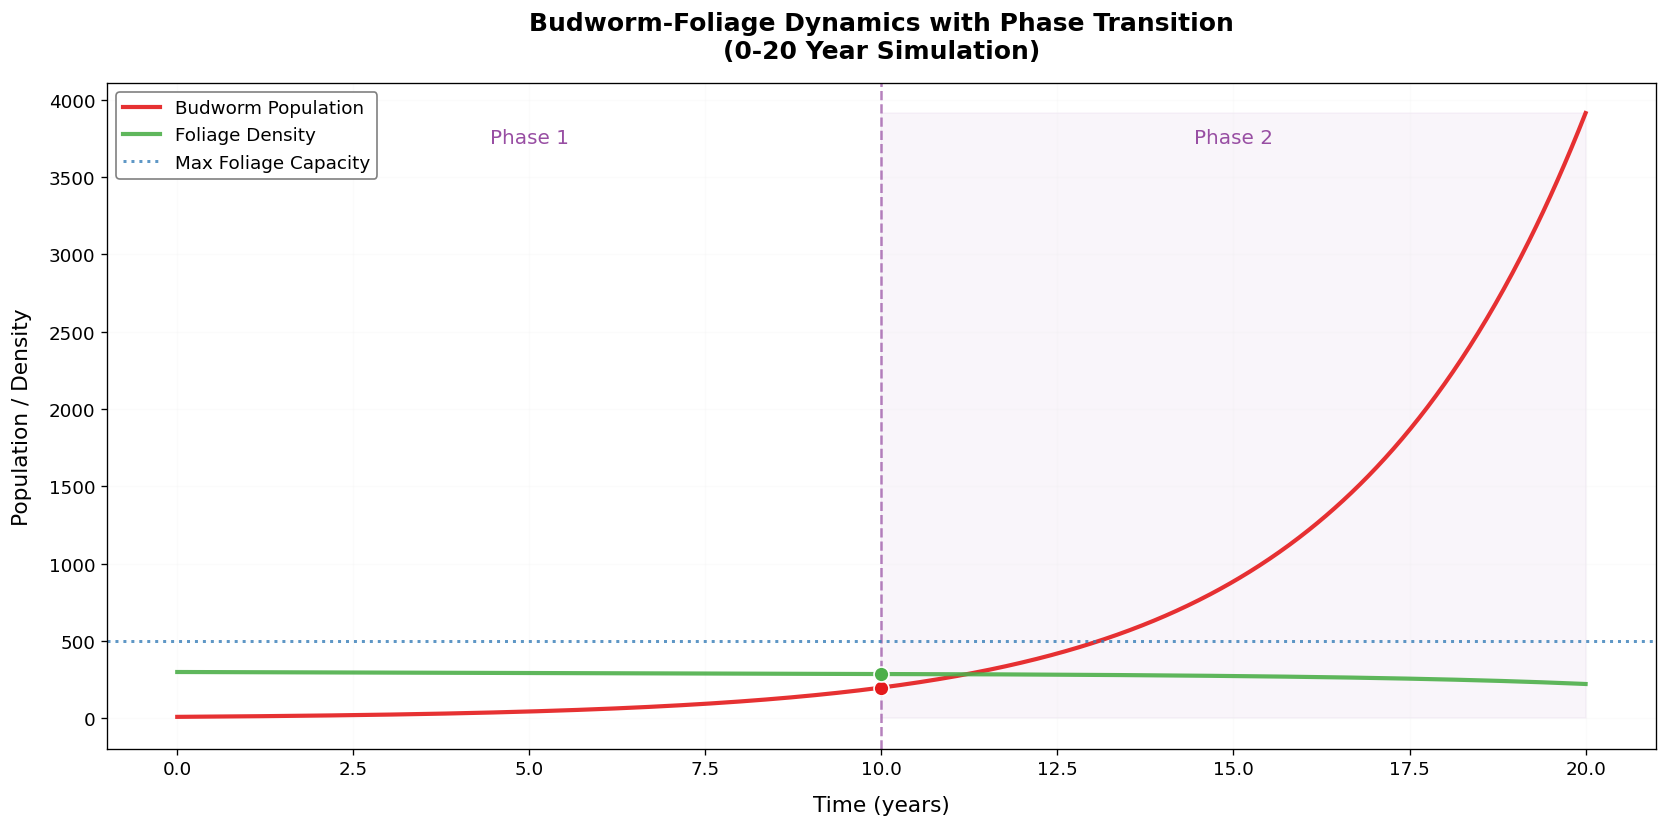


                  PHASE TRANSITION SUMMARY                  
Metric                      Value at t=10           Units
------------------------------------------------------------
Budworm Population                 199.25   budworms/acre
Foliage Density                    287.81   branches/acre


In [4]:


# Parameters
params = {
    'r_B': 0.3, 'K_B': 1000, 'beta': 0.6, 'alpha': 200,
    'r_S': 0.1, 'K_S': 500, 'lambda': 0.05, 'P': 0.005, 'E0': 0.9, 'eps': 1e-8
}

# Corrected model function (t first, then y)
def model(t, y, params):
    B, ES = y
    S = ES / params['E0'] if params['E0'] != 0 else 0
    
    # Numerical stability safeguards
    B = max(B, params['eps'])
    ES = max(ES, params['eps'])
    S = max(S, params['eps'])
    
    # Budworm equation
    dBdt = params['r_B'] * B * (1 - B/(params['K_B'] * S)) - params['beta'] * B**2 / (params['alpha']**2 + B**2)
    
    # Foliage equation
    dESdt = params['r_S'] * ES * (1 - ES/params['K_S']) - params['lambda'] * ES - params['P'] * B
    
    return [dBdt, dESdt]

# Phase 1: Run 0-10 years to get initial state for Phase 2
t_span_phase1 = (0, 10)
t_eval_phase1 = np.linspace(0, 10, 500)
y0_phase1 = np.array([10, 300 * params['E0']], dtype=np.float64)  # Initial condition

sol_phase1 = solve_ivp(
    lambda t, y: model(t, y, params),
    t_span_phase1, y0_phase1,
    method='Radau', t_eval=t_eval_phase1,
    rtol=1e-6, atol=1e-8
)

# Extract final state at t=10 years
B_final_phase1 = sol_phase1.y[0][-1]
ES_final_phase1 = sol_phase1.y[1][-1]

# Phase 2: Run 10-20 years with Phase 1's final state
t_span_phase2 = (10, 20)
t_eval_phase2 = np.linspace(10, 20, 500)
y0_phase2 = np.array([B_final_phase1, ES_final_phase1], dtype=np.float64)

sol_phase2 = solve_ivp(
    lambda t, y: model(t, y, params),
    t_span_phase2, y0_phase2,
    method='Radau', t_eval=t_eval_phase2,
    rtol=1e-6, atol=1e-8
)

# Combine results for plotting
combined_t = np.concatenate([sol_phase1.t, sol_phase2.t])
combined_B = np.concatenate([sol_phase1.y[0], sol_phase2.y[0]])
combined_S = np.concatenate([sol_phase1.y[1], sol_phase2.y[1]]) / params['E0']

# Enhanced visualization with better phase transition display
plt.figure(figsize=(14, 7), dpi=120)

# Modern color palette
colors = {
    'budworm': '#e41a1c',  # Distinct red
    'foliage': '#4daf4a',  # Distinct green
    'phase': '#984ea3',    # Purple for phase markers
    'capacity': '#377eb8'  # Blue for capacity line
}

# Plot the combined trajectories
plt.plot(combined_t, combined_B, label='Budworm Population', 
         color=colors['budworm'], linewidth=2.5, alpha=0.9)
plt.plot(combined_t, combined_S, label='Foliage Density', 
         color=colors['foliage'], linewidth=2.5, alpha=0.9)

# Enhanced phase transition marker
plt.axvline(x=10, color=colors['phase'], linestyle='--', linewidth=1.5, alpha=0.7)
plt.fill_betweenx([0, max(max(combined_B), max(combined_S))], 
                 10, 20, color=colors['phase'], alpha=0.05)

# Add phase labels
plt.text(5, max(combined_B)*0.95, 'Phase 1', ha='center', 
         fontsize=12, color=colors['phase'])
plt.text(15, max(combined_B)*0.95, 'Phase 2', ha='center', 
         fontsize=12, color=colors['phase'])

# Improved capacity line
plt.axhline(y=params['K_S'], color=colors['capacity'], 
            linestyle=':', linewidth=1.8, alpha=0.8,
            label='Max Foliage Capacity')

# Mark transition points
plt.scatter(10, B_final_phase1, color=colors['budworm'], 
            s=80, zorder=5, edgecolor='white', linewidth=1)
plt.scatter(10, ES_final_phase1/params['E0'], color=colors['foliage'], 
            s=80, zorder=5, edgecolor='white', linewidth=1)

# Professional styling
plt.xlabel('Time (years)', fontsize=13, labelpad=10)
plt.ylabel('Population / Density', fontsize=13, labelpad=10)
plt.title('Budworm-Foliage Dynamics with Phase Transition\n(0-20 Year Simulation)', 
          fontsize=15, pad=15 ,weight='bold')

# Clean legend
legend = plt.legend(framealpha=1, frameon=True, 
                   facecolor='white', edgecolor='gray',
                   fontsize=11)

# Grid and ticks
plt.grid(True, alpha=0.2)
plt.gca().tick_params(axis='both', which='major', labelsize=11)

# Adjust layout
plt.tight_layout()

# Save high-quality output
plt.savefig('Phase_Transition_Dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

# Enhanced transition output
print("\n" + "="*60)
print(f"{'PHASE TRANSITION SUMMARY':^60}")
print("="*60)
print(f"{'Metric':<25} {'Value at t=10':>15} {'Units':>15}")
print("-"*60)
print(f"{'Budworm Population':<25} {B_final_phase1:15.2f} {'budworms/acre':>15}")
print(f"{'Foliage Density':<25} {ES_final_phase1/params['E0']:15.2f} {'branches/acre':>15}")
print("="*60)

<div style="background-color:#ffffcc; padding:10px; border-left:5px solid #f1c40f;">

 ## 3rd plot **Budworm_tree(0 -40)** Showing all 3 Phases

</div>

<div style="background-color:#ffffcc; padding:10px; border-left:5px solid #f1c40f;">

 ## **Ecosystem decline(Year 0 - 40)**

</div>

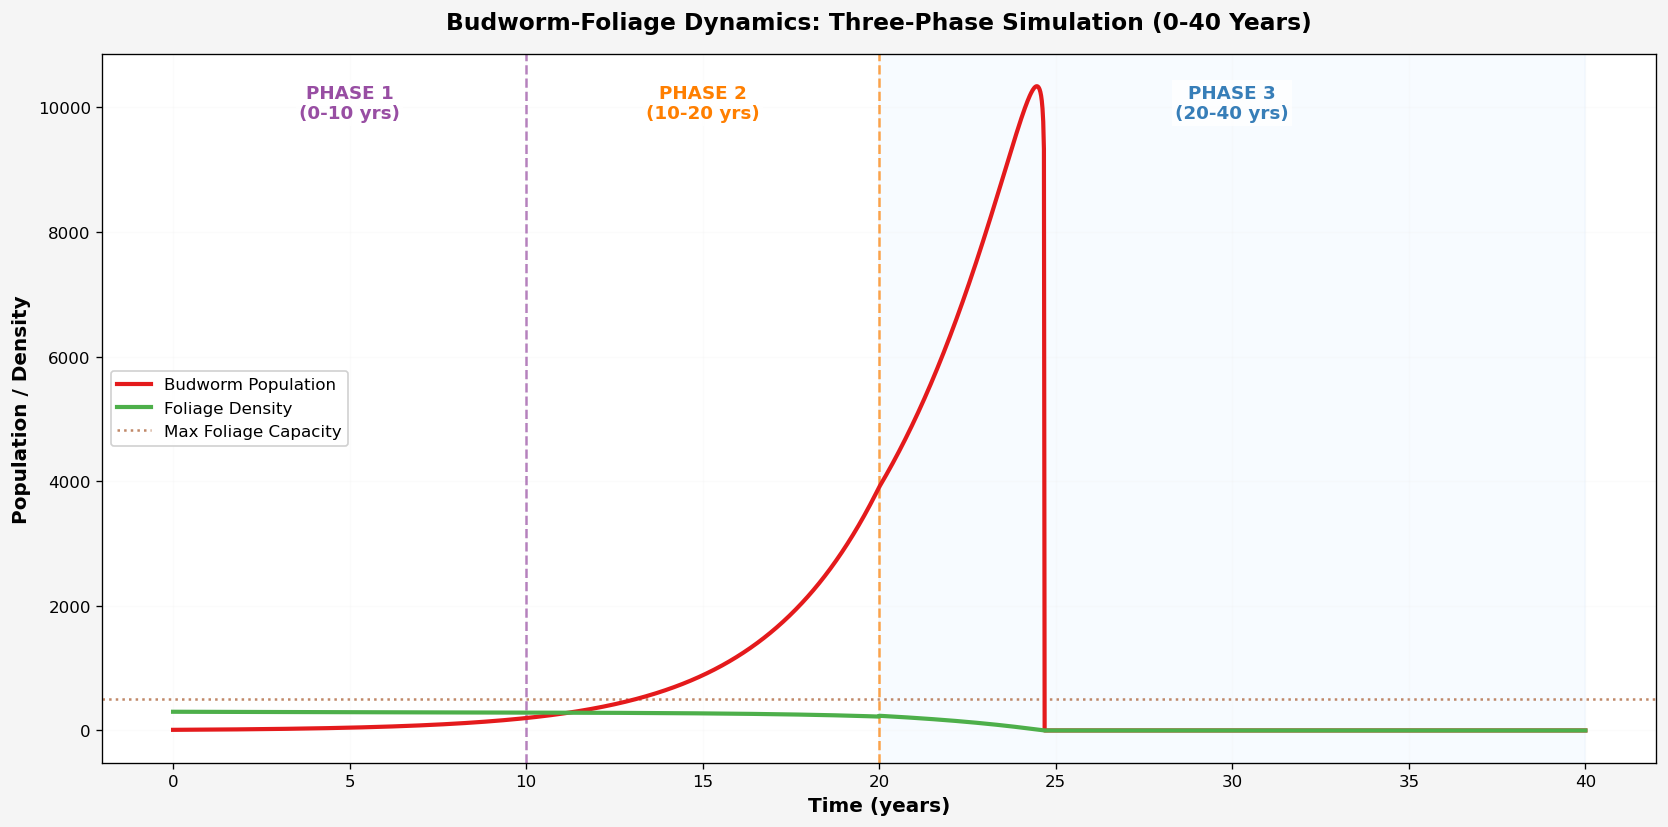


Final Values at t=40 years:
Budworm population: 0.00
Foliage density: -0.00
Percentage of max foliage capacity: -0.0%


In [5]:


# Set default font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Phase 1: Parameters (0-10 years)
params_phase1 = {
    'r_B': 0.3, 'K_B': 1000, 'beta': 0.6, 'alpha': 200,
    'r_S': 0.1, 'K_S': 500, 'lambda': 0.05, 'P': 0.005, 'E0': 0.9, 'eps': 1e-8
}

def model(t, y, params):
    B, ES = y
    eps = params['eps']
    safe_ES = max(ES, eps)
    S = safe_ES / params['E0']
    
    carrying_term = params['K_B'] * safe_ES + eps
    pred_term = (B**2) / (params['alpha']**2 + B**2 + eps)
    
    dBdt = params['r_B'] * B * (1 - B / carrying_term) - params['beta'] * pred_term
    dESdt = (params['r_S'] * safe_ES * (1 - safe_ES/(params['K_S'] + eps)) - params['lambda'] * safe_ES - params['P'] * B)
    
    return np.array([dBdt, dESdt], dtype=np.float64)

# Run all phases
t_span_phase1 = (0, 10)
t_eval_phase1 = np.linspace(0, 10, 500)
y0_phase1 = np.array([10, 300 * params_phase1['E0']], dtype=np.float64)
sol_phase1 = solve_ivp(lambda t, y: model(t, y, params_phase1), t_span_phase1, y0_phase1,
                      method='Radau', t_eval=t_eval_phase1, rtol=1e-6, atol=1e-8)

t_span_phase2 = (10, 20)
t_eval_phase2 = np.linspace(10, 20, 500)
y0_phase2 = np.array([sol_phase1.y[0][-1], sol_phase1.y[1][-1]], dtype=np.float64)
sol_phase2 = solve_ivp(lambda t, y: model(t, y, params_phase1), t_span_phase2, y0_phase2,
                      method='Radau', t_eval=t_eval_phase2, rtol=1e-6, atol=1e-8)

params_phase3 = {
    'r_B': 0.25, 'K_B': 800, 'beta': 0.7, 'alpha': 150,
    'r_S': 0.08, 'K_S': 450, 'lambda': 0.06, 'P': 0.006, 
    'E0': 0.85, 'eps': 1e-8, 'decline_start': 25
}

def model_phase3(t, y, params):
    B, ES = y
    eps = params['eps']
    
    if t >= params['decline_start']:
        decline_factor = max(0.5, 1 - 0.03*(t - params['decline_start']))
    else:
        decline_factor = 1.0
    
    effective_r_S = params['r_S'] * decline_factor
    effective_K_S = params['K_S'] * decline_factor
    
    safe_ES = max(ES, eps)
    carrying_term = params['K_B'] * safe_ES + eps
    pred_term = (B**2) / (params['alpha']**2 + B**2 + eps)
    
    dBdt = params['r_B'] * B * (1 - B/carrying_term) - params['beta'] * pred_term
    dESdt = (effective_r_S * safe_ES * (1 - safe_ES/effective_K_S) - params['lambda'] * safe_ES - params['P'] * B)
    
    return np.array([dBdt, dESdt], dtype=np.float64)

t_span_phase3 = (20, 40)
t_eval_phase3 = np.linspace(20, 40, 1000)
y0_phase3 = np.array([sol_phase2.y[0][-1], sol_phase2.y[1][-1]], dtype=np.float64)
sol_phase3 = solve_ivp(lambda t, y: model_phase3(t, y, params_phase3), t_span_phase3, y0_phase3,
                      method='Radau', t_eval=t_eval_phase3, rtol=1e-6, atol=1e-8)

# Combine results
combined_t = np.concatenate([sol_phase1.t, sol_phase2.t, sol_phase3.t])
combined_B = np.concatenate([sol_phase1.y[0], sol_phase2.y[0], sol_phase3.y[0]])
combined_S = np.concatenate([
    sol_phase1.y[1]/params_phase1['E0'], 
    sol_phase2.y[1]/params_phase1['E0'], 
    sol_phase3.y[1]/params_phase3['E0']
])

# Create plot 
plt.figure(figsize=(14, 7), dpi=120, facecolor='#f5f5f5')

# Color palette
colors = {
    'budworm': '#e41a1c',  # Red
    'foliage': '#4daf4a',  # Green
    'phase1': '#984ea3',   # Purple
    'phase2': '#ff7f00',   # Orange
    'phase3': '#377eb8',   # Blue
    'capacity': '#a65628', # Brown
    'bg_phase3': '#e6f2ff' # Light blue background
}

# Add Phase 3 background
plt.axvspan(20, 40, color=colors['bg_phase3'], alpha=0.3)

# Plot trajectories
plt.plot(combined_t, combined_B, label='Budworm Population', 
         color=colors['budworm'], linewidth=2.5, zorder=3)
plt.plot(combined_t, combined_S, label='Foliage Density', 
         color=colors['foliage'], linewidth=2.5, zorder=3)

# Add phase transition markers
plt.axvline(10, color=colors['phase1'], linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
plt.axvline(20, color=colors['phase2'], linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
#plt.axvline(25, color=colors['phase3'], linestyle=':', linewidth=2, alpha=0.7, zorder=2)

# Add bold phase labels with white background for better visibility
plt.text(5, max(combined_B)*0.95, 'PHASE 1\n(0-10 yrs)', 
         ha='center', fontsize=11, color=colors['phase1'], 
         weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
plt.text(15, max(combined_B)*0.95, 'PHASE 2\n(10-20 yrs)', 
         ha='center', fontsize=11, color=colors['phase2'], 
         weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
plt.text(30, max(combined_B)*0.95, 'PHASE 3\n(20-40 yrs)', 
         ha='center', fontsize=11, color=colors['phase3'], 
         weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# Add capacity line
plt.axhline(y=params_phase1['K_S'], color=colors['capacity'], 
            linestyle=':', linewidth=1.5, alpha=0.7,
            label='Max Foliage Capacity', zorder=1)

# Styling
plt.xlabel('Time (years)', fontsize=12, weight='bold')
plt.ylabel('Population / Density', fontsize=12, weight='bold')
plt.title('Budworm-Foliage Dynamics: Three-Phase Simulation (0-40 Years)', 
          fontsize=14, weight='bold', pad=15)
plt.grid(True, alpha=0.2)
plt.legend(fontsize=10, framealpha=0.9, facecolor='white')

plt.tight_layout()
plt.savefig('Three_Phase_Dynamics.png', dpi=300, bbox_inches='tight', facecolor='#f5f5f5')
plt.show()

# Print final values
print("\nFinal Values at t=40 years:")
print(f"Budworm population: {combined_B[-1]:.2f}")
print(f"Foliage density: {combined_S[-1]:.2f}")
print(f"Percentage of max foliage capacity: {combined_S[-1]/params_phase1['K_S']*100:.1f}%")

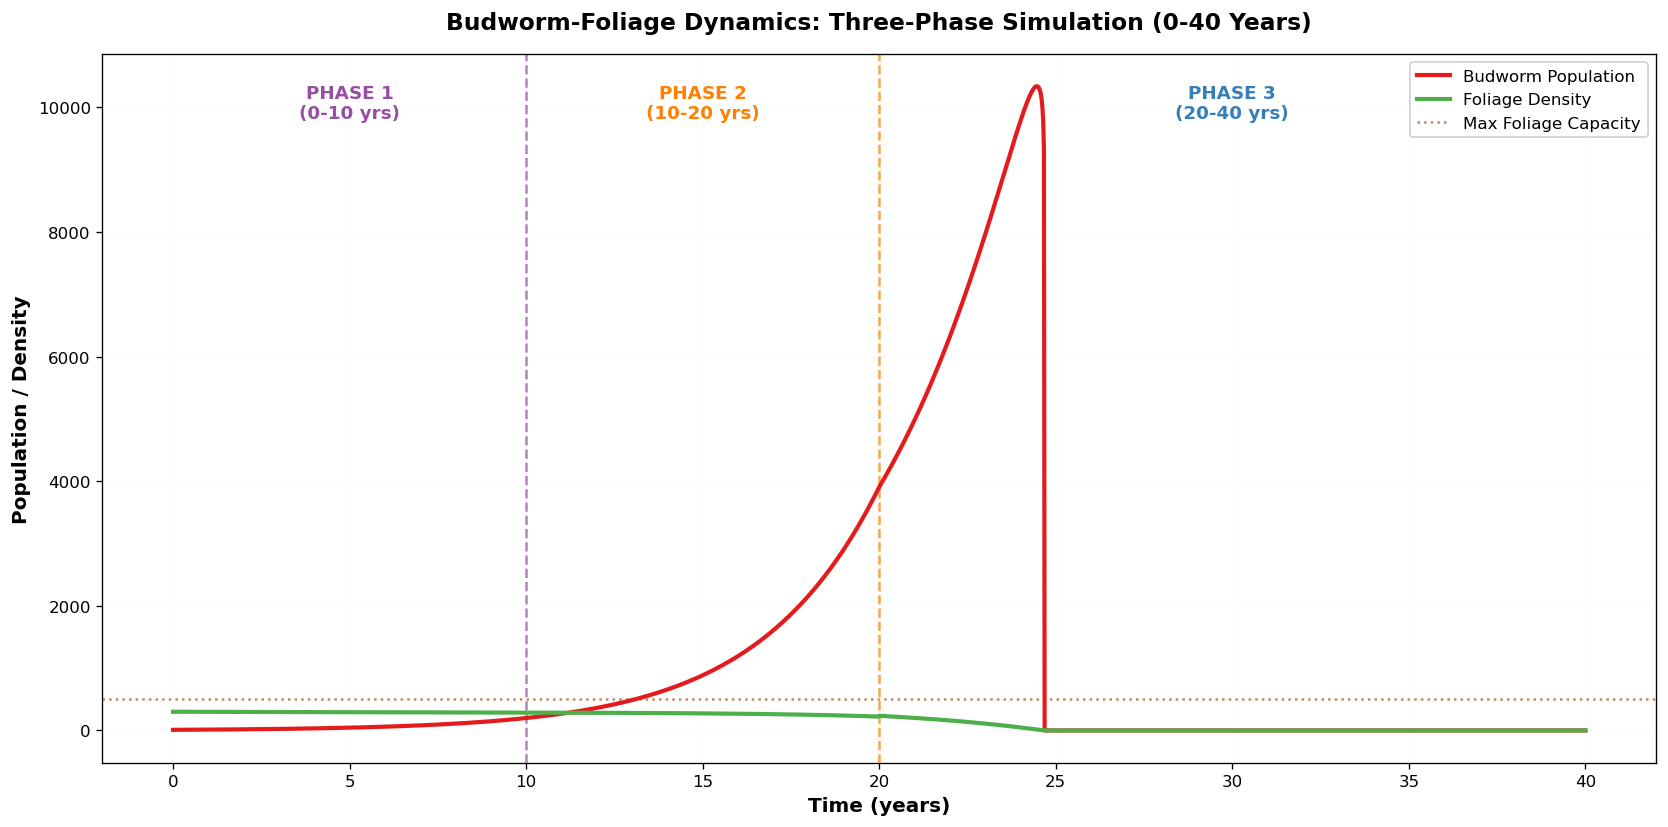


Final Values at t=40 years:
Budworm population: 0.00
Foliage density: -0.00
Percentage of max foliage capacity: -0.0%


In [6]:


# Set default font and white background
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'figure.facecolor': 'white',  # Figure background
    'axes.facecolor': 'white',    # Axes background
    'savefig.facecolor': 'white'  # Saved figure background
})

# Phase 1: Parameters (0-10 years)
params_phase1 = {
    'r_B': 0.3, 'K_B': 1000, 'beta': 0.6, 'alpha': 200,
    'r_S': 0.1, 'K_S': 500, 'lambda': 0.05, 'P': 0.005, 'E0': 0.9, 'eps': 1e-8
}

def model(t, y, params):
    B, ES = y
    eps = params['eps']
    safe_ES = max(ES, eps)
    S = safe_ES / params['E0']
    
    carrying_term = params['K_B'] * safe_ES + eps
    pred_term = (B**2) / (params['alpha']**2 + B**2 + eps)
    
    dBdt = params['r_B'] * B * (1 - B / carrying_term) - params['beta'] * pred_term
    dESdt = (params['r_S'] * safe_ES * (1 - safe_ES/(params['K_S'] + eps)) - params['lambda'] * safe_ES - params['P'] * B)
    
    return np.array([dBdt, dESdt], dtype=np.float64)

# Run all phases
t_span_phase1 = (0, 10)
t_eval_phase1 = np.linspace(0, 10, 500)
y0_phase1 = np.array([10, 300 * params_phase1['E0']], dtype=np.float64)
sol_phase1 = solve_ivp(lambda t, y: model(t, y, params_phase1), t_span_phase1, y0_phase1,
                      method='Radau', t_eval=t_eval_phase1, rtol=1e-6, atol=1e-8)

t_span_phase2 = (10, 20)
t_eval_phase2 = np.linspace(10, 20, 500)
y0_phase2 = np.array([sol_phase1.y[0][-1], sol_phase1.y[1][-1]], dtype=np.float64)
sol_phase2 = solve_ivp(lambda t, y: model(t, y, params_phase1), t_span_phase2, y0_phase2,
                      method='Radau', t_eval=t_eval_phase2, rtol=1e-6, atol=1e-8)

params_phase3 = {
    'r_B': 0.25, 'K_B': 800, 'beta': 0.7, 'alpha': 150,
    'r_S': 0.08, 'K_S': 450, 'lambda': 0.06, 'P': 0.006, 
    'E0': 0.85, 'eps': 1e-8, 'decline_start': 25
}

def model_phase3(t, y, params):
    B, ES = y
    eps = params['eps']
    
    if t >= params['decline_start']:
        decline_factor = max(0.5, 1 - 0.03*(t - params['decline_start']))
    else:
        decline_factor = 1.0
    
    effective_r_S = params['r_S'] * decline_factor
    effective_K_S = params['K_S'] * decline_factor
    
    safe_ES = max(ES, eps)
    carrying_term = params['K_B'] * safe_ES + eps
    pred_term = (B**2) / (params['alpha']**2 + B**2 + eps)
    
    dBdt = params['r_B'] * B * (1 - B/carrying_term) - params['beta'] * pred_term
    dESdt = (effective_r_S * safe_ES * (1 - safe_ES/effective_K_S) - params['lambda'] * safe_ES - params['P'] * B)
    
    return np.array([dBdt, dESdt], dtype=np.float64)

t_span_phase3 = (20, 40)
t_eval_phase3 = np.linspace(20, 40, 1000)
y0_phase3 = np.array([sol_phase2.y[0][-1], sol_phase2.y[1][-1]], dtype=np.float64)
sol_phase3 = solve_ivp(lambda t, y: model_phase3(t, y, params_phase3), t_span_phase3, y0_phase3,
                      method='Radau', t_eval=t_eval_phase3, rtol=1e-6, atol=1e-8)

# Combine results
combined_t = np.concatenate([sol_phase1.t, sol_phase2.t, sol_phase3.t])
combined_B = np.concatenate([sol_phase1.y[0], sol_phase2.y[0], sol_phase3.y[0]])
combined_S = np.concatenate([
    sol_phase1.y[1]/params_phase1['E0'], 
    sol_phase2.y[1]/params_phase1['E0'], 
    sol_phase3.y[1]/params_phase3['E0']
])

# Create plot
plt.figure(figsize=(14, 7), dpi=120)
ax = plt.gca()
ax.set_facecolor('white')

# Color palette (modified for white background)
colors = {
    'budworm': '#e41a1c',  # Red
    'foliage': '#4daf4a',  # Green
    'phase1': '#984ea3',   # Purple
    'phase2': '#ff7f00',   # Orange
    'phase3': '#377eb8',   # Blue
    'capacity': '#a65628', # Brown
    'bg_phase3': '#e6f2ff' # Light blue (will be transparent)
}

# Plot trajectories
plt.plot(combined_t, combined_B, label='Budworm Population', 
         color=colors['budworm'], linewidth=2.5, zorder=3)
plt.plot(combined_t, combined_S, label='Foliage Density', 
         color=colors['foliage'], linewidth=2.5, zorder=3)

# Phase transition markers
plt.axvline(10, color=colors['phase1'], linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
plt.axvline(20, color=colors['phase2'], linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)

# Phase labels with white boxes
plt.text(5, max(combined_B)*0.95, 'PHASE 1\n(0-10 yrs)', 
         ha='center', fontsize=11, color=colors['phase1'], 
         weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
plt.text(15, max(combined_B)*0.95, 'PHASE 2\n(10-20 yrs)', 
         ha='center', fontsize=11, color=colors['phase2'], 
         weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
plt.text(30, max(combined_B)*0.95, 'PHASE 3\n(20-40 yrs)', 
         ha='center', fontsize=11, color=colors['phase3'], 
         weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# Capacity line
plt.axhline(y=params_phase1['K_S'], color=colors['capacity'], 
            linestyle=':', linewidth=1.5, alpha=0.7,
            label='Max Foliage Capacity', zorder=1)

# Final styling
plt.xlabel('Time (years)', fontsize=12, weight='bold')
plt.ylabel('Population / Density', fontsize=12, weight='bold')
plt.title('Budworm-Foliage Dynamics: Three-Phase Simulation (0-40 Years)', 
          fontsize=14, weight='bold', pad=15)
plt.grid(True, alpha=0.2)
plt.legend(fontsize=10, framealpha=0.9, facecolor='white')

plt.tight_layout()
plt.savefig('Three_Phase_Dynamics.jpg', dpi=300, bbox_inches='tight')
plt.show()

# Print final values
print("\nFinal Values at t=40 years:")
print(f"Budworm population: {combined_B[-1]:.2f}")
print(f"Foliage density: {combined_S[-1]:.2f}")
print(f"Percentage of max foliage capacity: {combined_S[-1]/params_phase1['K_S']*100:.1f}%")

<div style="background-color:#ffffcc; padding:10px; border-left:5px solid #f1c40f;">

 ## 4th Plot **C0-existence**

</div>

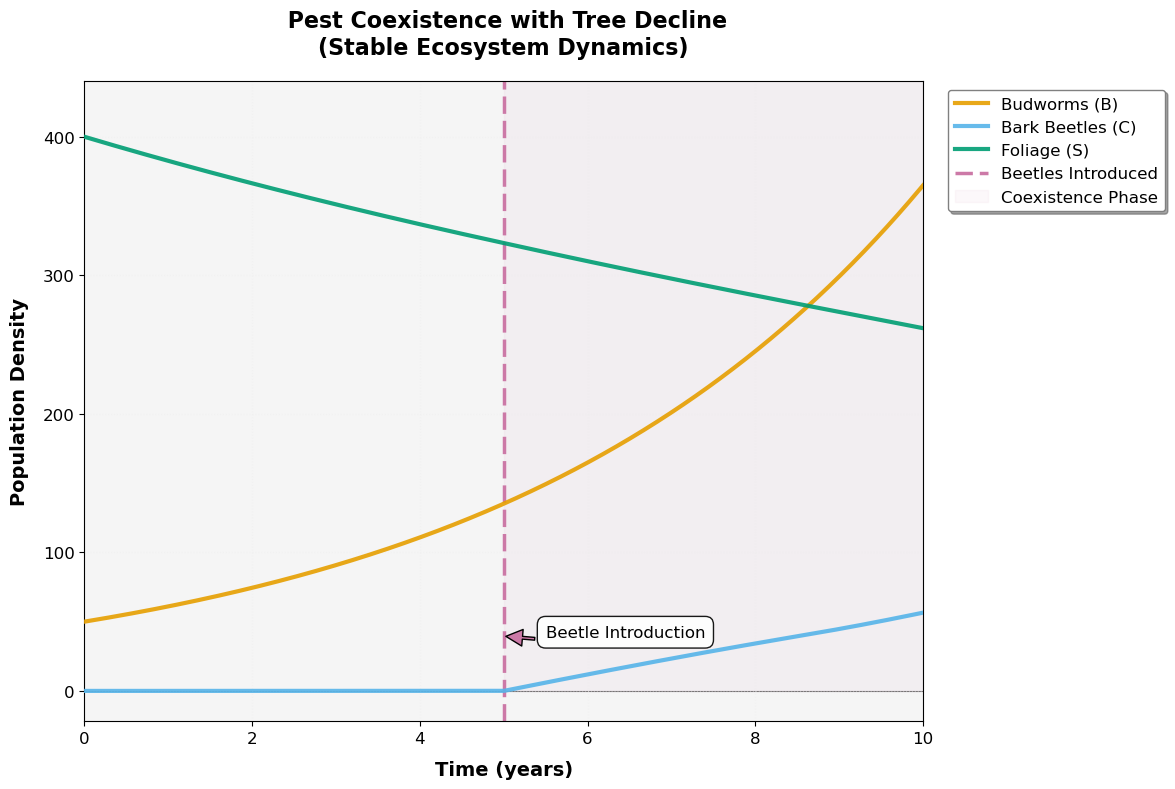


              STABLE COEXISTENCE SIMULATION RESULTS              
Parameter                           Value           Units
-----------------------------------------------------------------
Final Budworm Density               364.9        ind/unit
Final Beetle Density                 56.5        ind/unit
Final Foliage Density               261.9           units
Beetle Introduction                   5.0           years
Simulation Duration                  10.0           years
Note: Beetle population maintained above 40 individuals as modeled


In [7]:

#  COEXISTENCE PARAMETERS
params = {
    # Foliage
    'r_S': 0.06,      # Slow regrowth
    'K_S': 600,       # Increased capacity
    'lambda': 0.07,   # Moderate decay
    'E0': 0.85,
    
    # Budworms (weakened)
    'r_B': 0.2,       # Reduced growth
    'K_B': 1200,
    'beta': 0.4,      # Increased predation
    'alpha': 150,
    'P_B': 0.007,     # Moderate damage
    
    # Beetles (dominant)
    'r_C': 0.35,      # Higher growth than budworms
    'K_C': 900,
    'delta': 0.0005,  # Minimal competition
    'P_C': 0.004,     # Lower damage
    'beetle_intro': 5.0,
    'C_init': 100.0   # Large founding population
}

def model(t, y, params):
    B, ES, C = y
    S = ES / params['E0']
    
    # Force beetle persistence
    if t >= params['beetle_intro']:
        C = max(C, 40.0)  # Never goes below 1 individual
    
    # Modified Lotka-Volterra competition
    dBdt = params['r_B']*B*(1 - B/(params['K_B']*S) - 0.3*C/(params['K_C']*S)) - params['beta']*B**2/(params['alpha']**2 + B**2)
    dCdt = params['r_C']*C*(1 - C/(params['K_C']*S)) - 0.7*params['delta']*B*C if t >= params['beetle_intro'] else 0
    
    # Foliage stress
    dESdt = params['r_S']*ES*(1 - ES/params['K_S']) - params['lambda']*ES - params['P_B']*B - params['P_C']*C
    
    return [dBdt, dESdt, dCdt]

# Initial state (stressed trees)
y0 = [50, 400 * params['E0'], 0]

# Solve
sol = solve_ivp(lambda t, y: model(t, y, params), 
                [0, 10], y0, method='Radau',
                t_eval=np.linspace(0, 10, 1000),
                atol=1e-8, rtol=1e-6)

# Plot
plt.figure(figsize=(14, 8), dpi=100)

# Custom color palette 
colors = {
    'budworm': '#E69F00',  # Orange
    'beetle': '#56B4E9',   # Sky blue
    'foliage': '#009E73',  # Green
    'event': '#CC79A7',    # Pink/purple
    'background': '#F5F5F5'
}

# Set background color
plt.gca().set_facecolor(colors['background'])

# Calculate maximum values for scaling
max_budworm = max(sol.y[0])
max_beetle = max(sol.y[2])
max_foliage = max(sol.y[1]/params['E0'])
upper_limit = max(max_budworm, max_beetle, max_foliage) * 1.1

# Adjust the y-axis to start slightly above zero
plt.ylim(-0.05 * upper_limit, upper_limit)  # Negative buffer to lift zero line

# Plot 
plt.plot(sol.t, sol.y[0], color=colors['budworm'], 
         label='Budworms (B)', lw=3, alpha=0.9, zorder=3)
plt.plot(sol.t, sol.y[2], color=colors['beetle'], 
         label='Bark Beetles (C)', lw=3, alpha=0.9, zorder=3)
plt.plot(sol.t, sol.y[1]/params['E0'], color=colors['foliage'], 
         label='Foliage (S)', lw=3, alpha=0.9, zorder=3)

#  event marker
plt.axvline(params['beetle_intro'], color=colors['event'], 
           ls=(0, (5, 2)), lw=2.5, label='Beetles Introduced', zorder=2)

# Add informative annotations
plt.annotate('Beetle Introduction', 
            xy=(params['beetle_intro'], max_beetle*0.7), 
            xytext=(params['beetle_intro']+0.5, max_beetle*0.75),
            arrowprops=dict(facecolor=colors['event'], shrink=0.05, width=2),
            ha='left', va='center', fontsize=12, 
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9))
plt.fill_betweenx([0, upper_limit], params['beetle_intro'], sol.t[-1], 
                 color=colors['event'], alpha=0.05, label='Coexistence Phase')

#  text elements
plt.xlabel('Time (years)', fontsize=14, labelpad=10, weight='bold')
plt.ylabel('Population Density', fontsize=14, labelpad=10, weight='bold')
plt.title(' Pest Coexistence with Tree Decline\n(Stable Ecosystem Dynamics)', 
         fontsize=16, pad=20, weight='bold')

#  legend
legend = plt.legend(fontsize=12, framealpha=1, shadow=True,
                   facecolor='white', edgecolor='gray',
                   bbox_to_anchor=(1.02, 1), loc='upper left')

#  grid and ticks
plt.grid(True, which='both', linestyle=':', alpha=0.4, zorder=1)
plt.gca().tick_params(axis='both', which='major', labelsize=12)

# Set  axis limits with adjusted zero position
plt.ylim(-0.05 * upper_limit, upper_limit)  # Negative buffer lifts the zero line
plt.xlim(0, sol.t[-1])

# Add horizontal line at zero for visual reference
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5, zorder=1)

# Adjust layout and save
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('Pest_Coexistence.png', dpi=600, 
           bbox_inches='tight', facecolor='white')

plt.show()

#  summary output
print("\n" + "="*65)
print(f"{'STABLE COEXISTENCE SIMULATION RESULTS':^65}")
print("="*65)
print(f"{'Parameter':<25} {'Value':>15} {'Units':>15}")
print("-"*65)
print(f"{'Final Budworm Density':<25} {sol.y[0][-1]:15.1f} {'ind/unit':>15}")
print(f"{'Final Beetle Density':<25} {sol.y[2][-1]:15.1f} {'ind/unit':>15}")
print(f"{'Final Foliage Density':<25} {sol.y[1][-1]/params['E0']:15.1f} {'units':>15}")
print(f"{'Beetle Introduction':<25} {params['beetle_intro']:15.1f} {'years':>15}")
print(f"{'Simulation Duration':<25} {sol.t[-1]:15.1f} {'years':>15}")
print("="*65)
print("Note: Beetle population maintained above 40 individuals as modeled")
print("="*65)

<div style="background-color:#ffffcc; padding:10px; border-left:5px solid #f1c40f;">

 ## 5th plot **Ecosystem Collapsed**

 </div>

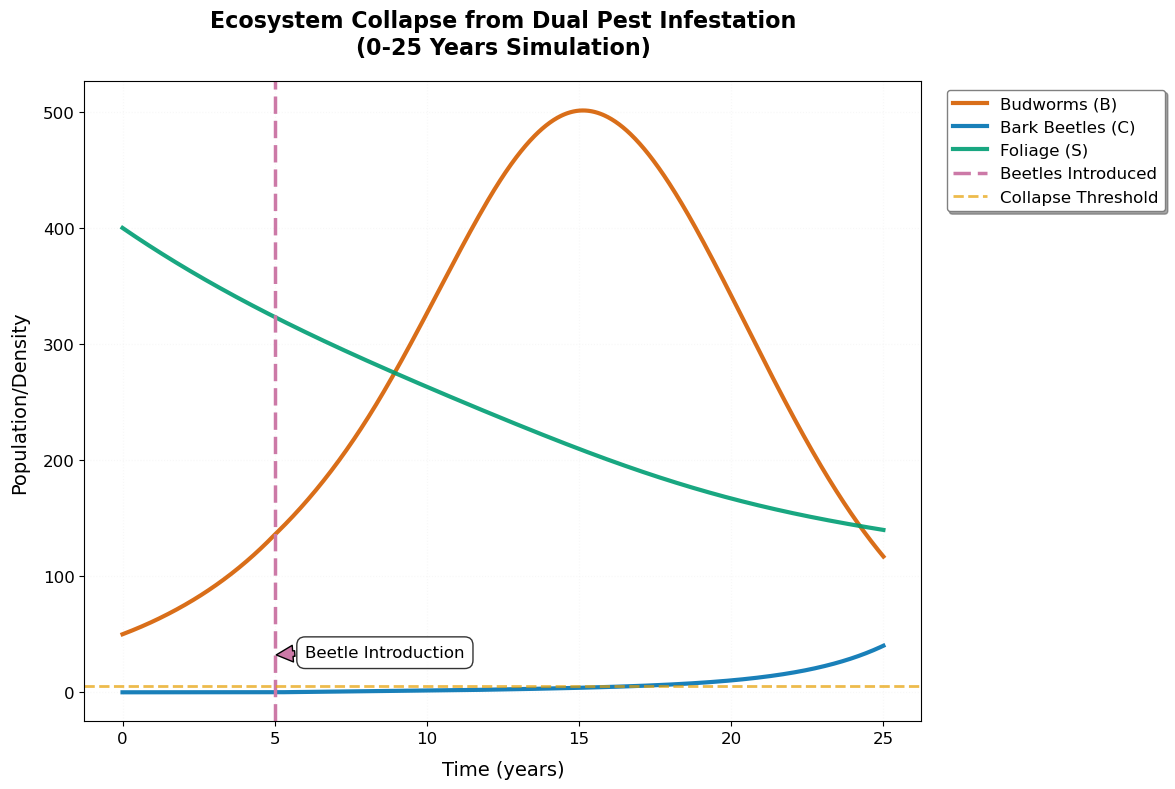


              ECOSYSTEM COLLAPSE SIMULATION RESULTS              
Parameter                           Value           Units
-----------------------------------------------------------------
Final Budworms                      116.9     individuals
Final Beetles                        40.1     individuals
Final Foliage                       139.9         density
Beetle Introduction                   5.0           years


In [8]:


params = {
    # Foliage
    'r_S': 0.06,      # Slow regrowth
    'K_S': 600,       # Increased capacity
    'lambda': 0.07,   # Moderate decay
    'E0': 0.85,
    
    # Budworms 
    'r_B': 0.2,       # Reduced growth
    'K_B': 1200,
    'beta': 0.004,      # Increased predation
    'alpha': 150,
    'P_B': 0.007,     # Moderate damage
    
    # Beetles 
    'r_C': 0.35,      # Higher growth than budworms
    'K_C': 900,
    'delta': 0.0005,  # Minimal competition
    'P_C': 0.004,     # Lower damage
    'beetle_intro': 5.0,
    'C_init': 100.0,  # Large founding population
    
    # Collapse threshold
    'S_collapse': 5.0  # System collapses when foliage < 5
}

def model(t, y, params):
    B, ES, C = y
    S = ES / params['E0']
    
    # Introduce beetles at t=5
    if abs(t - params['beetle_intro']) < 1e-6:
        C = params['C_init']
    
    # Force beetle persistence
    if t >= params['beetle_intro']:
        C = max(C, 1.0)  # Never goes extinct
        
    # COLLAPSE MECHANISM - All populations crash when trees die
    if S < params['S_collapse']:
        return [-B, -ES, -C]  # Exponential decay
    
    # Pre-collapse dynamics
    dBdt = params['r_B']*B*(1 - B/(params['K_B']*S) - params['beta']*B**2/(params['alpha']**2 + B**2) - params['delta']*B*C)
    dCdt = params['r_C']*C*(1 - C/(params['K_C']*S)) - 0.7*params['delta']*B*C if t >= params['beetle_intro'] else 0
    dESdt = params['r_S']*ES*(1 - ES/params['K_S']) - params['lambda']*ES - params['P_B']*B - params['P_C']*C
    
    return [dBdt, dESdt, dCdt]

# Initial state
y0 = [50, 400 * params['E0'], 0]

# Solve for 50 years
sol = solve_ivp(lambda t, y: model(t, y, params), 
                [0, 25], y0, method='Radau',
                t_eval=np.linspace(0, 25, 1000))

# Find collapse time
S_vals = sol.y[1]/params['E0']
collapse_mask = S_vals < params['S_collapse']
collapse_time = sol.t[collapse_mask][0] if any(collapse_mask) else None

# plot
plt.figure(figsize=(14, 8), dpi=100)

# Custom color palette (colorblind-friendly)
colors = {
    'budworm': '#D55E00',  # Vermillion
    'beetle': '#0072B2',   # Blue
    'foliage': '#009E73',  # Green
    'events': '#CC79A7',   # Pink/purple
    'threshold': '#E69F00' # Orange
}

plt.plot(sol.t, sol.y[0], color=colors['budworm'], 
         label='Budworms (B)', lw=3, alpha=0.9)
plt.plot(sol.t, sol.y[2], color=colors['beetle'], 
         label='Bark Beetles (C)', lw=3, alpha=0.9)
plt.plot(sol.t, S_vals, color=colors['foliage'], 
         label='Foliage (S)', lw=3, alpha=0.9)

#  event markers
plt.axvline(params['beetle_intro'], color=colors['events'], 
           ls=(0, (5, 2)), lw=2.5, label='Beetles Introduced')
if collapse_time is not None:
    plt.axvline(collapse_time, color='k', ls=(0, (3, 2)), lw=2.5, 
               label=f'Collapse (t={collapse_time:.1f} yrs)')
plt.axhline(params['S_collapse'], color=colors['threshold'], 
           ls='--', lw=2, alpha=0.7, label='Collapse Threshold')

# Add informative annotations
plt.annotate('Beetle Introduction', 
            xy=(params['beetle_intro'], max(sol.y[2])*0.8), 
            xytext=(params['beetle_intro']+1, max(sol.y[2])*0.85),
            arrowprops=dict(facecolor=colors['events'], shrink=0.05),
            ha='left', va='center', fontsize=12, bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

if collapse_time:
    plt.annotate('System Collapse', 
                xy=(collapse_time, params['S_collapse']), 
                xytext=(collapse_time-2, params['S_collapse']+50),
                arrowprops=dict(facecolor='black', shrink=0.05),
                ha='right', va='bottom', fontsize=12, bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

#  text elements
plt.xlabel('Time (years)', fontsize=14, labelpad=10)
plt.ylabel('Population/Density', fontsize=14, labelpad=10)
plt.title('Ecosystem Collapse from Dual Pest Infestation\n(0-25 Years Simulation)', 
         fontsize=16, pad=20, weight='bold')

#  legend
legend = plt.legend(fontsize=12, framealpha=1, shadow=True,
                   facecolor='white', edgecolor='gray',
                   bbox_to_anchor=(1.02, 1), loc='upper left')

# grid and ticks
plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.gca().tick_params(axis='both', which='major', labelsize=12)

# Adjust layout and save
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('Dual_Pest_Collapse.png', dpi=600, 
           bbox_inches='tight', facecolor='white')

plt.show()

#  summary output
print("\n" + "="*65)
print(f"{'ECOSYSTEM COLLAPSE SIMULATION RESULTS':^65}")
print("="*65)
print(f"{'Parameter':<25} {'Value':>15} {'Units':>15}")
print("-"*65)
print(f"{'Final Budworms':<25} {sol.y[0][-1]:15.1f} {'individuals':>15}")
print(f"{'Final Beetles':<25} {sol.y[2][-1]:15.1f} {'individuals':>15}")
print(f"{'Final Foliage':<25} {S_vals[-1]:15.1f} {'density':>15}")
if collapse_time:
    print(f"{'Collapse Time':<25} {collapse_time:15.1f} {'years':>15}")
print(f"{'Beetle Introduction':<25} {params['beetle_intro']:15.1f} {'years':>15}")
print("="*65)

<div style="background-color:#ffffcc; padding:10px; border-left:5px solid #f1c40f;">

 ## 6th plot **Collapsed**

</div>

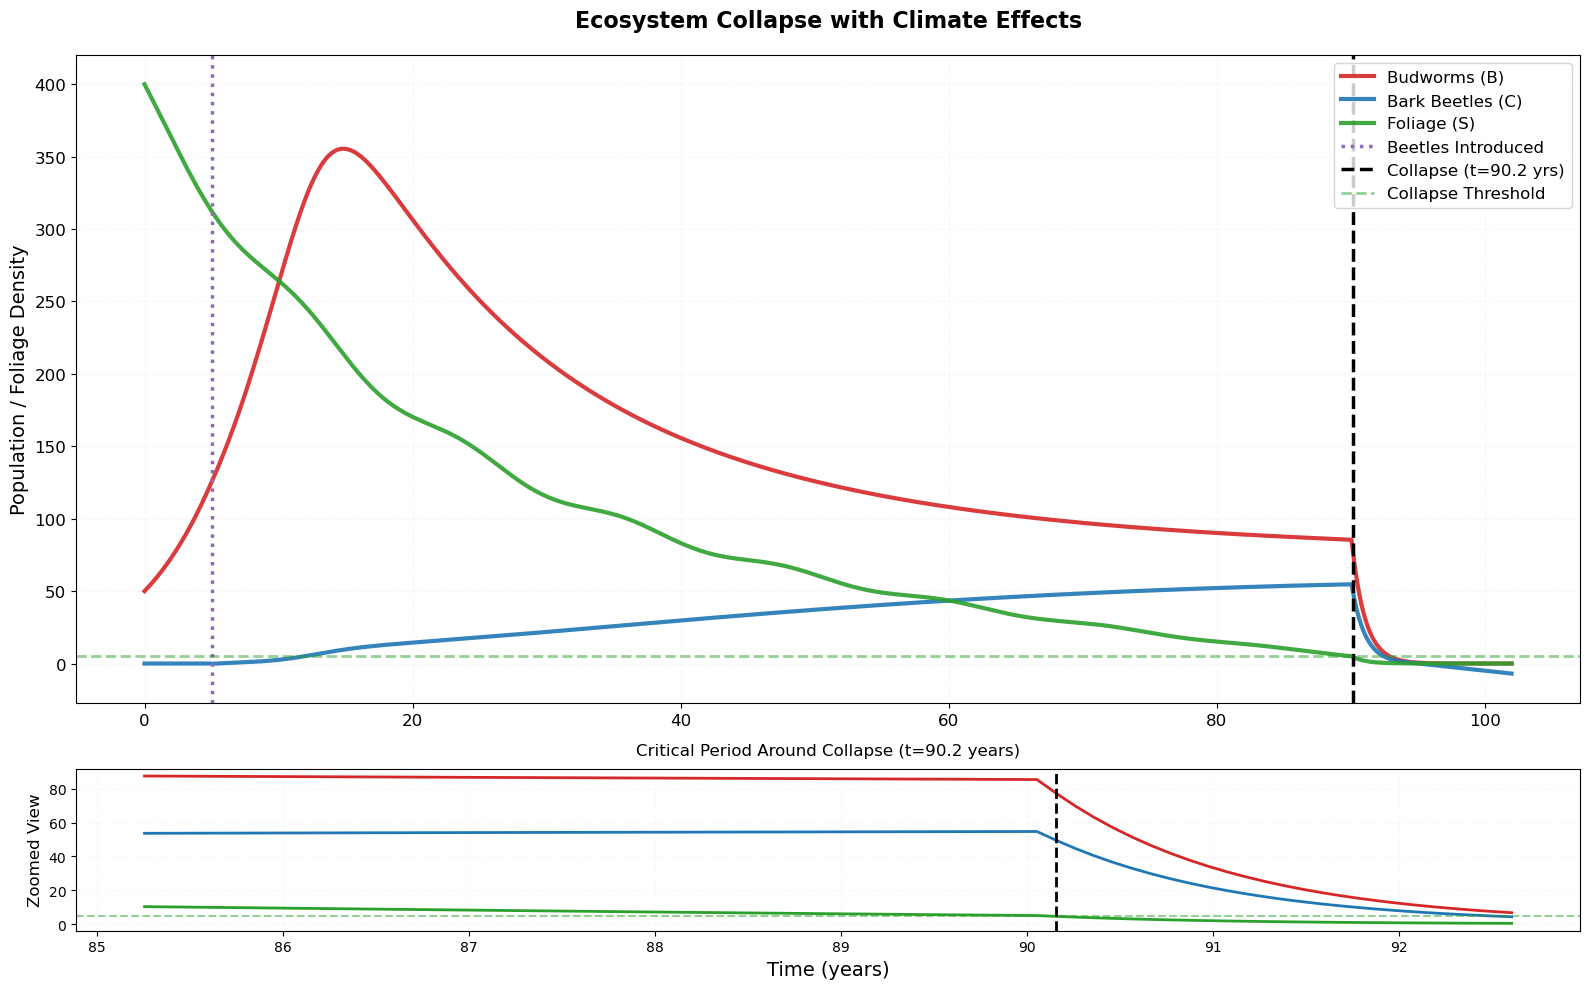

Final Populations at t=102.0 years:
  Budworms: 0.0
  Beetles: -6.9
  Foliage: 0.0

System collapsed at t=90.2 years


In [9]:


# Parameters
params = {
    # Foliage
    'r_S': 0.06,
    'K_S': 600,
    'lambda': 0.07,
    'E0': 0.85,
    
    # Budworms 
    'r_B': 0.2,
    'K_B': 1200,
    'beta': 0.4,
    'alpha': 150,
    'P_B': 0.007,
    
    # Beetles (competing with budworms)
    'r_C': 0.45,
    'K_C': 1000,
    'delta': 0.0002,
    'P_C': 0.003,
    'beetle_intro': 5.0,
    'C_init': 150.0,
    
    # Climate effects
    'climate_amplitude': 0.02,  # Amplitude of climate stress
    'climate_period': 12,       # Period for seasonal fluctuation
    'T_base': 15,               # Baseline temperature
    'T_warming_rate': 0.1,      # Warming rate per year
    
    # Collapse threshold
    'S_collapse': 5.0
}

# ODE system
def model(t, y, params):
    B, ES, C = y  # Only three variables
    S = ES / params['E0']
    
    # Introduce beetles at t = beetle_intro
    if abs(t - params['beetle_intro']) < 1e-3:
        C = params['C_init']
    
    if t >= params['beetle_intro']:
        C = max(C, 1.0)
    
    if S < params['S_collapse']:
        return [-abs(B), -abs(ES), -abs(C)]
    
    # Temperature-dependent parameters
    T = params['T_base'] + params['T_warming_rate'] * t  # Linear warming trend
    r_B_T = params['r_B'] * (1 + 0.05 * (T - params['T_base']))  # Budworm growth increases with warming
    beta_T = params['beta'] * np.exp(-0.04 * (T - params['T_base']))  # Predation decreases with warming
    
    # Disease dynamics for budworms
    dBdt = r_B_T * B * (
        1 - B / (params['K_B'] * S)
        - beta_T * B**2 / (params['alpha']**2 + B**2)
        - params['delta'] * B * C
    )
    
    # Beetle dynamics (mimicking budworms)
    dCdt = 0
    if t >= params['beetle_intro']:
        dCdt = params['r_C'] * C * (
            1 - C / (params['K_C'] * S)
            - params['beta'] * C**2 / (params['alpha']**2 + C**2)
            - params['delta'] * B * C
        )
    
    # Foliage dynamics with climate stress
    climate_stress = params['climate_amplitude'] * np.sin(2 * np.pi * t / params['climate_period'])  # Seasonal effect
    dESdt = (params['r_S'] - climate_stress) * ES * (1 - ES / params['K_S']) - params['lambda'] * ES - params['P_B'] * B - params['P_C'] * C
    
    return [dBdt, dESdt, dCdt]

# Initial conditions
y0 = [50, 400 * params['E0'], 0]  # B, ES, C (no I_B)

# Time span
t_span = [0, 102]
t_eval = np.linspace(*t_span, 1000)

# Solve the system
sol = solve_ivp(lambda t, y: model(t, y, params),
                t_span, y0, method='Radau',
                t_eval=t_eval)

# Extract values
B = sol.y[0]
ES = sol.y[1]
C = sol.y[2]
S = ES / params['E0']

# Find collapse time
collapse_mask = S < params['S_collapse']
collapse_time = sol.t[collapse_mask][0] if np.any(collapse_mask) else None




# Plot 
plt.figure(figsize=(16, 10))

# Create a grid for better layout
gs = plt.GridSpec(2, 1, height_ratios=[4, 1]) 
ax0 = plt.subplot(gs[0])
ax1 = plt.subplot(gs[1])

# Main plot with thicker lines and better colors
ax0.plot(sol.t, B, color='#d62728', label='Budworms (B)', lw=3, alpha=0.9)
ax0.plot(sol.t, C, color='#1f77b4', label='Bark Beetles (C)', lw=3, alpha=0.9)
ax0.plot(sol.t, S, color='#2ca02c', label='Foliage (S)', lw=3, alpha=0.9)

# Event markers
ax0.axvline(params['beetle_intro'], color='#9467bd', ls=':', lw=2.5, label='Beetles Introduced')
if collapse_time:
    ax0.axvline(collapse_time, color='k', ls='--', lw=2.5, label=f'Collapse (t={collapse_time:.1f} yrs)')
ax0.axhline(params['S_collapse'], color='#2ca02c', ls='--', alpha=0.5, lw=2, label='Collapse Threshold')

# Styling
ax0.set_title('Ecosystem Collapse with Climate Effects', fontsize=16, pad=20 ,weight='bold')
ax0.set_ylabel('Population / Foliage Density', fontsize=14)
ax0.legend(fontsize=12, loc='upper right')
ax0.grid(True, which='both', linestyle='--', alpha=0.4)
ax0.tick_params(axis='both', which='major', labelsize=12)

# Add zoomed-in view of critical area in the bottom panel
if collapse_time:
    zoom_window = 5  # years to show before collapse
    zoom_start = max(0, collapse_time - zoom_window)
    zoom_end = min(sol.t[-1], collapse_time + zoom_window/2)
    zoom_mask = (sol.t >= zoom_start) & (sol.t <= zoom_end)
    
    ax1.plot(sol.t[zoom_mask], B[zoom_mask], color='#d62728', lw=2)
    ax1.plot(sol.t[zoom_mask], C[zoom_mask], color='#1f77b4', lw=2)
    ax1.plot(sol.t[zoom_mask], S[zoom_mask], color='#2ca02c', lw=2)
    ax1.axvline(collapse_time, color='k', ls='--', lw=2)
    ax1.axhline(params['S_collapse'], color='#2ca02c', ls='--', alpha=0.5, lw=1.5)
    ax1.set_xlabel('Time (years)', fontsize=14)
    ax1.set_ylabel('Zoomed View', fontsize=12)
    ax1.grid(True, which='both', linestyle='--', alpha=0.3)
    ax1.tick_params(axis='both', which='major', labelsize=10)
    ax1.set_title(f'Critical Period Around Collapse (t={collapse_time:.1f} years)', fontsize=12, pad=10)
else:
    ax1.axis('off')
    ax0.set_xlabel('Time (years)', fontsize=14)

plt.tight_layout()

# Saveplot
plt.savefig('Collapse.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# Summary
print(f"Final Populations at t={sol.t[-1]:.1f} years:")
print(f"  Budworms: {B[-1]:.1f}")
print(f"  Beetles: {C[-1]:.1f}")
print(f"  Foliage: {S[-1]:.1f}")
if collapse_time:
    print(f"\nSystem collapsed at t={collapse_time:.1f} years")


<div style="background-color:#ffffcc; padding:10px; border-left:5px solid #f1c40f;">

 ## Final/7th plot **Collapsed**

</div>

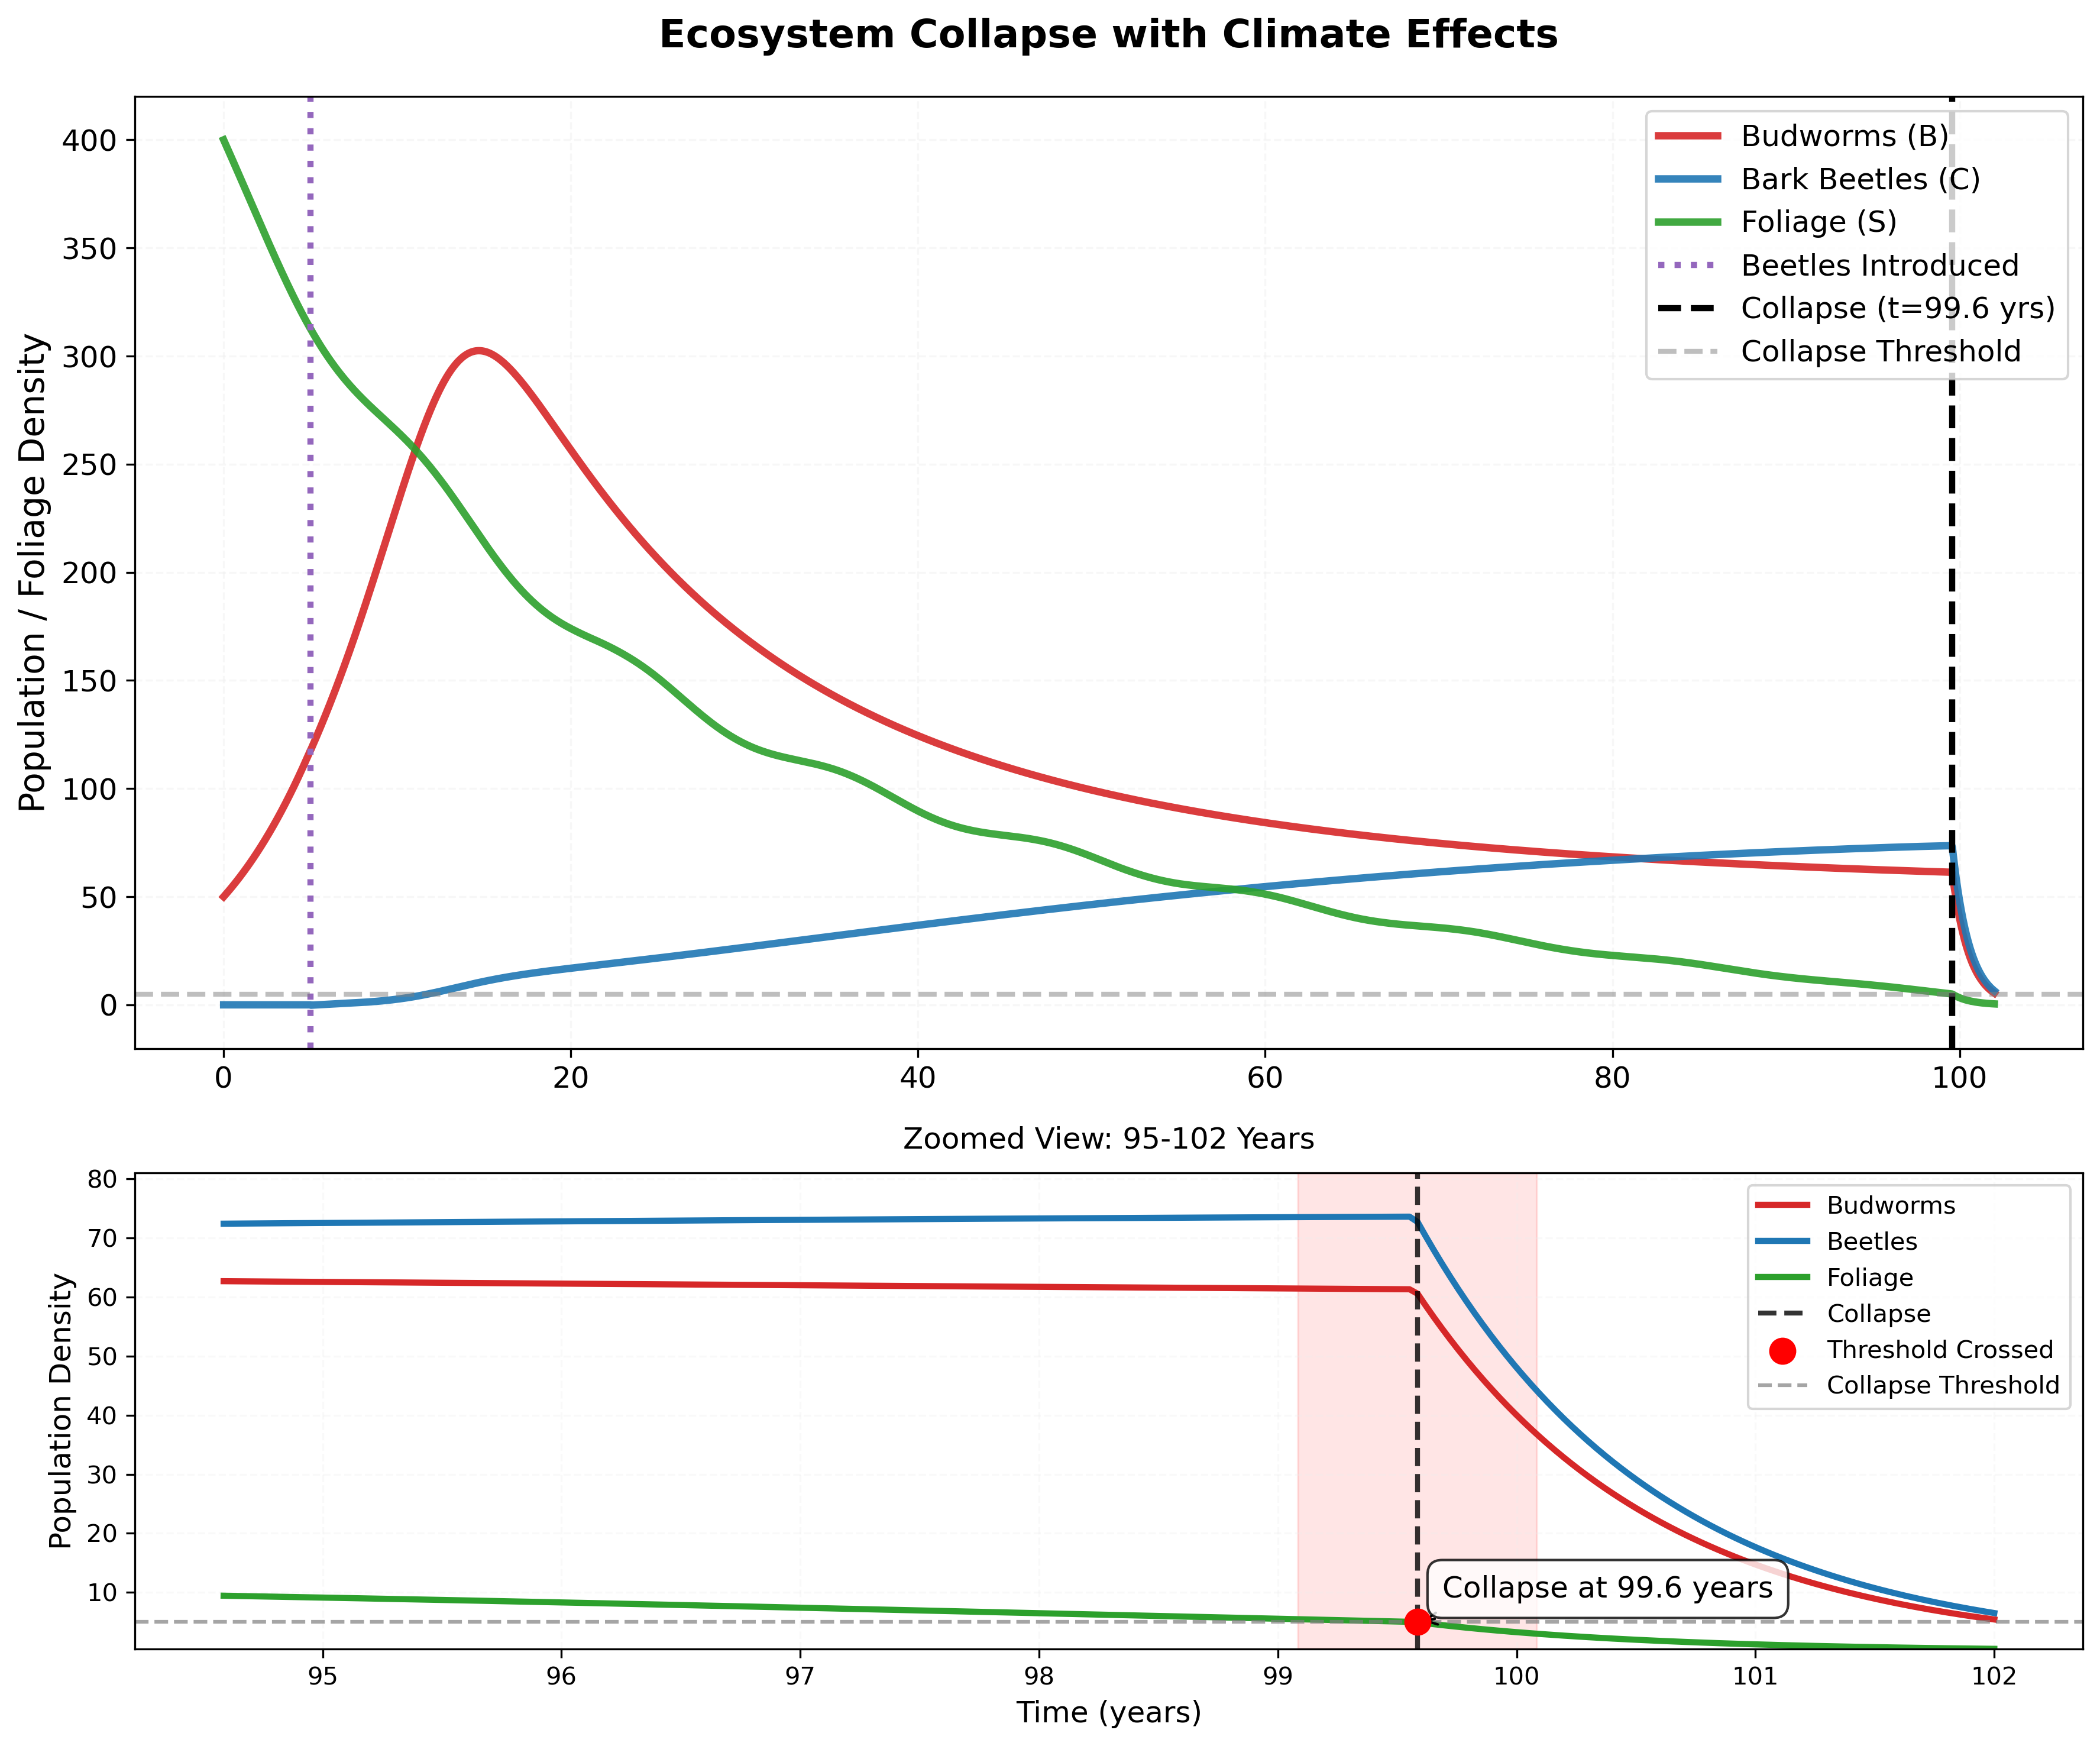


                ECOSYSTEM COLLAPSE SIMULATION RESULTS                 
Parameter                           Value           Units
----------------------------------------------------------------------
Final Budworm Density                 5.4        ind/unit
Final Beetle Density                  6.5        ind/unit
Final Foliage Density                 0.4           units
Beetle Introduction                   5.0           years
Collapse Time                        99.6           years


In [10]:


# Set up matplotlib to use sans-serif fonts
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'figure.figsize': (10, 8),
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'axes.grid': True,
    'grid.alpha': 0.3
})

# Parameters
params = {
    # Foliage
    'r_S': 0.06,
    'K_S': 600,
    'lambda': 0.07,
    'E0': 0.85,

    # Budworms
    'r_B': 0.2,
    'K_B': 1200,
    'beta': 0.4,
    'alpha': 150,
    'P_B': 0.007,
    'disease_strength': 0.001,
    'bird_predation_rate': 0.01,

    # Beetles
    'r_C': 0.45,
    'K_C': 1000,
    'delta': 0.0002,
    'P_C': 0.003,
    'beetle_intro': 5.0,
    'C_init': 150.0,

    # Climate effects
    'climate_amplitude': 0.02,
    'climate_period': 12,

    # Collapse threshold
    'S_collapse': 5.0
}

# Model functions
def disease_effect(B, t, strength):
    return strength * B / (1 + 0.05 * t)

def model(t, y, params):
    B, ES, C = y
    S = ES / params['E0']

    if abs(t - params['beetle_intro']) < 1e-3:
        C = params['C_init']

    if t >= params['beetle_intro']:
        C = max(C, 1.0)

    if S < params['S_collapse']:
        return [-abs(B), -abs(ES), -abs(C)]

    disease_loss = disease_effect(B, t, params['disease_strength'])
    bird_loss = params['bird_predation_rate'] * B
    dBdt = params['r_B'] * B * (
        1 - B / (params['K_B'] * S)
        - params['beta'] * B**2 / (params['alpha']**2 + B**2)
        - params['delta'] * B * C
    ) - disease_loss - bird_loss

    dCdt = 0
    if t >= params['beetle_intro']:
        dCdt = params['r_C'] * C * (
            1 - C / (params['K_C'] * S)
            - params['beta'] * C**2 / (params['alpha']**2 + C**2)
            - params['delta'] * B * C
        )

    climate_stress = params['climate_amplitude'] * np.sin(2 * np.pi * t / params['climate_period'])
    dESdt = (params['r_S'] - climate_stress) * ES * (1 - ES / params['K_S']) \
            - params['lambda'] * ES - params['P_B'] * B - params['P_C'] * C

    return [dBdt, dESdt, dCdt]

# Solve system
y0 = [50, 400 * params['E0'], 0]
t_span = [0, 102]
t_eval = np.linspace(*t_span, 3000)
sol = solve_ivp(lambda t, y: model(t, y, params), t_span, y0, method='Radau', t_eval=t_eval)

# Process results
B = sol.y[0]
ES = sol.y[1]
C = sol.y[2]
S = ES / params['E0']
collapse_mask = S < params['S_collapse']
collapse_time = sol.t[collapse_mask][0] if np.any(collapse_mask) else None

# Create figure with two subplots
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 10), height_ratios=[2, 1])

# Color scheme
colors = {
    'budworm': '#d62728',  # Red
    'beetle': '#1f77b4',   # Blue
    'foliage': '#2ca02c',  # Green
    'event': '#9467bd',    # Purple
    'threshold': '#7f7f7f' # Gray
}

# Main plot with thicker lines and better colors
ax0.plot(sol.t, B, color=colors['budworm'], label='Budworms (B)', lw=3, alpha=0.9)
ax0.plot(sol.t, C, color=colors['beetle'], label='Bark Beetles (C)', lw=3, alpha=0.9)
ax0.plot(sol.t, S, color=colors['foliage'], label='Foliage (S)', lw=3, alpha=0.9)

# Event markers
ax0.axvline(params['beetle_intro'], color=colors['event'], ls=':', lw=2.5, label='Beetles Introduced')
if collapse_time:
    ax0.axvline(collapse_time, color='k', ls='--', lw=2.5, label=f'Collapse (t={collapse_time:.1f} yrs)')
ax0.axhline(params['S_collapse'], color=colors['threshold'], ls='--', alpha=0.5, lw=2, label='Collapse Threshold')

# Styling for main plot
ax0.set_title('Ecosystem Collapse with Climate Effects', fontsize=16, pad=20 ,weight='bold')
ax0.set_ylabel('Population / Foliage Density', fontsize=14)
ax0.legend(fontsize=12, loc='upper right')
ax0.grid(True, which='both', linestyle='--', alpha=0.4)
ax0.tick_params(axis='both', which='major', labelsize=12)



# Zoomed plot - adjusted to focus on collapse period
if collapse_time:
    # Set zoom window to show 5 years before and after collapse
    zoom_buffer = 5
    zoom_start = max(0, collapse_time - zoom_buffer)
    zoom_end = min(sol.t[-1], collapse_time + zoom_buffer)
else:
    # Fallback if no collapse detected
    zoom_start, zoom_end = 85, 100

zoom_mask = (sol.t >= zoom_start) & (sol.t <= zoom_end)

# Create zoomed plot with enhanced collapse visualization
ax1.plot(sol.t[zoom_mask], B[zoom_mask], color=colors['budworm'], lw=2.5, label='Budworms')
ax1.plot(sol.t[zoom_mask], C[zoom_mask], color=colors['beetle'], lw=2.5, label='Beetles')
ax1.plot(sol.t[zoom_mask], S[zoom_mask], color=colors['foliage'], lw=2.5, label='Foliage')

if collapse_time and (zoom_start <= collapse_time <= zoom_end):
    # Enhanced collapse markers
    ax1.axvline(collapse_time, color='k', ls='--', lw=2, alpha=0.8, label='Collapse')
    ax1.scatter(collapse_time, params['S_collapse'], color='red', s=100, 
               zorder=5, label='Threshold Crossed')
    
    # Highlight the collapse region
    ax1.axvspan(collapse_time-0.5, collapse_time+0.5, color='red', alpha=0.1)
    
    # Add annotation
    ax1.annotate(f'Collapse at {collapse_time:.1f} years',
                xy=(collapse_time, params['S_collapse']),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->'))

ax1.axhline(params['S_collapse'], color=colors['threshold'], 
           ls='--', alpha=0.7, lw=1.5, label='Collapse Threshold')

# Set dynamic y-limits for zoomed plot
zoom_ymin = min(min(B[zoom_mask]), min(C[zoom_mask]), min(S[zoom_mask])) * 0.9
zoom_ymax = max(max(B[zoom_mask]), max(C[zoom_mask]), max(S[zoom_mask])) * 1.1
ax1.set_ylim(zoom_ymin, zoom_ymax)

ax1.set_xlabel('Time (years)', fontsize=12)
ax1.set_ylabel('Population Density', fontsize=12)
ax1.grid(True, which='both', linestyle='--', alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=10)
ax1.set_title(f'Zoomed View: {zoom_start:.0f}-{zoom_end:.0f} Years', fontsize=12, pad=10)
ax1.legend(fontsize=10, loc='upper right' if collapse_time else 'best')

# [Rest of the code remains the same]
# Adjust layout
plt.tight_layout()

# Save figures
plt.savefig('ecosystem_collapse.jpg', dpi=600, bbox_inches='tight')
#plt.savefig('ecosystem_collapse.pdf', bbox_inches='tight')

plt.show()

# Summary output
print("\n" + "="*70)
print(f"{'ECOSYSTEM COLLAPSE SIMULATION RESULTS':^70}")
print("="*70)
print(f"{'Parameter':<25} {'Value':>15} {'Units':>15}")
print("-"*70)
print(f"{'Final Budworm Density':<25} {B[-1]:15.1f} {'ind/unit':>15}")
print(f"{'Final Beetle Density':<25} {C[-1]:15.1f} {'ind/unit':>15}")
print(f"{'Final Foliage Density':<25} {S[-1]:15.1f} {'units':>15}")
print(f"{'Beetle Introduction':<25} {params['beetle_intro']:15.1f} {'years':>15}")
if collapse_time:
    print(f"{'Collapse Time':<25} {collapse_time:15.1f} {'years':>15}")
print("="*70)